# How a Decision Tree Splits — Gini Impurity From Scratch

Imagine you are sorting a box of mixed red and blue balls into two smaller boxes. Your goal: after each split, each box should contain mostly one colour. A decision tree does exactly this with data — it keeps asking yes/no questions about the features ("is x1 ≤ 3.5?") and splits the data into groups, until every group contains only one class.

The question the tree asks at every step is: **which split makes the resulting groups least mixed?** To measure "mixedness" it uses a number called **Gini impurity**. This notebook builds that logic from scratch, split by split, and visualises every step.

## The Dataset

We have 10 points described by two features — `x1` and `x2` — and a binary label `y` (Yes / No). The label pattern is NOT linearly separable by a single line, so the tree will need **three levels of splits** to fully separate the data.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

x1 = [1,  2,  3,  4,  5,  6,  7,  8,  9, 10]
x2 = [5,  8,  3,  6,  7,  2,  4,  9, 10,  1]
y  = ['No','No','No','Yes','Yes','No','No','Yes','Yes','Yes']

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df

,x1,x2,y
0,1,5,No
1,2,8,No
2,3,3,No
3,4,6,Yes
4,5,7,Yes
5,6,2,No
6,7,4,No
7,8,9,Yes
8,9,10,Yes
9,10,1,Yes


## Gini Impurity — The Measuring Stick

Before the tree can decide WHERE to split, it needs a way to measure how mixed a group is. That measure is **Gini impurity**.

For a group with two classes (Yes / No):

$$\text{Gini} = 1 - (p_{\text{Yes}}^2 + p_{\text{No}}^2)$$

- If the group is **pure** (all one class): Gini = 0  
- If the group is **perfectly mixed** (50/50 split): Gini = 0.5  

A split creates two child groups. We evaluate the split using the **weighted Gini** — a weighted average of the children's Gini values, weighted by how many points went to each side:

$$\text{Weighted Gini} = \frac{n_L}{n} \cdot \text{Gini}_L + \frac{n_R}{n} \cdot \text{Gini}_R$$

The tree always picks the split with the **lowest weighted Gini**.

In [45]:
def gini(labels):
    total = len(labels)
    if total == 0:
        return 0
    p_yes = (labels == 'Yes').sum() / total
    p_no  = (labels == 'No').sum()  / total
    return 1 - (p_yes**2 + p_no**2)

root_gini = gini(df['y'])
print(f"Root Gini impurity: {root_gini:.4f}")
print(f"  Yes: {(df['y']=='Yes').sum()}  No: {(df['y']=='No').sum()}  Total: {len(df)}")

Root Gini impurity: 0.5000
  Yes: 5  No: 5  Total: 10


### Two types of Gini — don't mix them up

You will see the word "Gini" used in two different ways throughout this notebook. They measure different things:

| | What it measures | When it appears |
|---|---|---|
| **Node Gini** | How mixed the points *inside a single node* are right now | Shown in each tree box |
| **Weighted Gini** | How good a particular split threshold is | Used to compare and pick splits |

**Node Gini** is just the formula above applied to one group:
$$\text{Node Gini} = 1 - (p_{\text{Yes}}^2 + p_{\text{No}}^2)$$

**Weighted Gini** averages the two children *after* a proposed split, weighted by size:
$$\text{Weighted Gini} = \frac{n_L}{n} \cdot \text{Gini}_L \;+\; \frac{n_R}{n} \cdot \text{Gini}_R$$

The algorithm uses weighted Gini to *choose* the best split. Once the split is made, each child gets its own node Gini. If a child's node Gini is 0 it is pure — no further splitting needed (it becomes a leaf). If it is greater than 0 the whole process repeats on that child.

## Finding the Best Split — the Core Logic

For every feature, the tree tries every possible threshold (the midpoint between consecutive values). For each candidate threshold it computes the weighted Gini and keeps the one that gives the lowest value. The function below does this for a given subset of the data.

In [46]:
def find_best_split(data, features=['x1', 'x2']):
    best_gini   = 1.0
    best_feat   = None
    best_thresh = None
    n = len(data)

    rows = []
    for feat in features:
        sorted_vals = sorted(data[feat].unique())
        thresholds  = [(sorted_vals[i] + sorted_vals[i+1]) / 2
                       for i in range(len(sorted_vals) - 1)]

        for thresh in thresholds:
            left  = data[data[feat] <= thresh]['y']
            right = data[data[feat] >  thresh]['y']

            wg = (len(left)/n) * gini(left) + (len(right)/n) * gini(right)

            rows.append({
                'feature':   feat,
                'threshold': thresh,
                'left_gini':  round(gini(left),  4),
                'right_gini': round(gini(right), 4),
                'weighted_gini': round(wg, 4)
            })

            if wg < best_gini:
                best_gini   = wg
                best_feat   = feat
                best_thresh = thresh

    results = pd.DataFrame(rows).sort_values('weighted_gini').reset_index(drop=True)
    return best_feat, best_thresh, round(best_gini, 4), results

---
## Split 1 — The Root Node

The algorithm starts with all 10 points. It tries every feature and every threshold, computes the weighted Gini for each, and picks the winner.

In [47]:
feat1, thresh1, wg1, results1 = find_best_split(df)

print(f"Best split: {feat1} ≤ {thresh1}  →  weighted Gini = {wg1}\n")
print("All splits ranked:")
print(results1.to_string(index=False))

Best split: x1 ≤ 3.5  →  weighted Gini = 0.2857

All splits ranked:
feature  threshold  left_gini  right_gini  weighted_gini
     x1        3.5     0.0000      0.4082         0.2857
     x1        7.5     0.4082      0.0000         0.2857
     x2        5.5     0.3200      0.3200         0.3200
     x1        8.5     0.4688      0.0000         0.3750
     x1        2.5     0.0000      0.4688         0.3750
     x2        8.5     0.4688      0.0000         0.3750
     x2        4.5     0.3750      0.4444         0.4167
     x1        6.5     0.4444      0.3750         0.4167
     x2        6.5     0.4444      0.3750         0.4167
     x1        4.5     0.3750      0.4444         0.4167
     x2        1.5     0.0000      0.4938         0.4444
     x1        1.5     0.0000      0.4938         0.4444
     x2        9.5     0.4938      0.0000         0.4444
     x1        9.5     0.4938      0.0000         0.4444
     x2        7.5     0.4898      0.4444         0.4762
     x2        3.5  

The best split at the root is `x1 ≤ 3.5`. Let us look at what the two groups look like and visualise the split line on a scatter plot.

In [48]:
left1  = df[df[feat1] <= thresh1].copy()
right1 = df[df[feat1] >  thresh1].copy()

print(f"LEFT  (x1 ≤ {thresh1}): {len(left1)} points, Gini = {gini(left1['y']):.4f}")
print(left1[['x1','x2','y']].to_string(index=False))
print()
print(f"RIGHT (x1 > {thresh1}): {len(right1)} points, Gini = {gini(right1['y']):.4f}")
print(right1[['x1','x2','y']].to_string(index=False))

LEFT  (x1 ≤ 3.5): 3 points, Gini = 0.0000
 x1  x2  y
  1   5 No
  2   8 No
  3   3 No

RIGHT (x1 > 3.5): 7 points, Gini = 0.4082
 x1  x2   y
  4   6 Yes
  5   7 Yes
  6   2  No
  7   4  No
  8   9 Yes
  9  10 Yes
 10   1 Yes


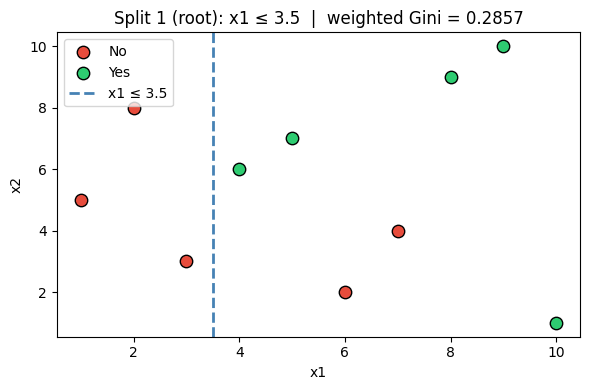

In [49]:
colors = {'Yes': '#2ecc71', 'No': '#e74c3c'}

def scatter_split(data, feat, thresh, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    for label, grp in data.groupby('y'):
        ax.scatter(grp['x1'], grp['x2'], c=colors[label], label=label,
                   s=80, edgecolors='k', zorder=3)
    if feat == 'x1':
        ax.axvline(thresh, color='steelblue', linewidth=2, linestyle='--', label=f'x1 ≤ {thresh}')
    else:
        ax.axhline(thresh, color='steelblue', linewidth=2, linestyle='--', label=f'x2 ≤ {thresh}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

fig, ax = plt.subplots(figsize=(6, 4))
scatter_split(df, feat1, thresh1,
              f'Split 1 (root): {feat1} ≤ {thresh1}  |  weighted Gini = {wg1}', ax)
plt.tight_layout()
plt.show()

---
## Split 2 — Check Each Child

After the root split we have two groups. We check each one:
- **Left branch** (`x1 ≤ 3.5`) — if Gini = 0 it is already pure and becomes a **leaf node**. No more splitting needed.  
- **Right branch** (`x1 > 3.5`) — if Gini > 0 it is still mixed, so we repeat the whole process on just those points.

In [50]:
print("=== LEFT branch (x1 ≤ 3.5) ===")
print(f"Labels: {left1['y'].tolist()}")
print(f"Gini  : {gini(left1['y']):.4f}")
print("→ Gini = 0.0  →  LEAF NODE — predict 'No'\n")

print("=== RIGHT branch (x1 > 3.5) ===")
print(f"Labels: {right1['y'].tolist()}")
print(f"Gini  : {gini(right1['y']):.4f}")
print("→ Gini > 0   →  still mixed, need another split")

=== LEFT branch (x1 ≤ 3.5) ===
Labels: ['No', 'No', 'No']
Gini  : 0.0000
→ Gini = 0.0  →  LEAF NODE — predict 'No'

=== RIGHT branch (x1 > 3.5) ===
Labels: ['Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes']
Gini  : 0.4082
→ Gini > 0   →  still mixed, need another split


The right branch has 7 points — a mix of Yes and No. We now run `find_best_split` on those 7 points only, considering both `x1` and `x2` again.

In [51]:
feat2, thresh2, wg2, results2 = find_best_split(right1)

print(f"Best split for right branch: {feat2} ≤ {thresh2}  →  weighted Gini = {wg2}\n")
print("All splits ranked:")
print(results2.to_string(index=False))

Best split for right branch: x2 ≤ 5.0  →  weighted Gini = 0.1905

All splits ranked:
feature  threshold  left_gini  right_gini  weighted_gini
     x2        5.0     0.4444      0.0000         0.1905
     x1        7.5     0.5000      0.0000         0.2857
     x2        6.5     0.5000      0.0000         0.2857
     x1        5.5     0.0000      0.4800         0.3429
     x1        8.5     0.4800      0.0000         0.3429
     x2        8.0     0.4800      0.0000         0.3429
     x2        3.0     0.5000      0.3200         0.3714
     x1        9.5     0.4444      0.0000         0.3810
     x1        4.5     0.0000      0.4444         0.3810
     x2        1.5     0.0000      0.4444         0.3810
     x2        9.5     0.4444      0.0000         0.3810
     x1        6.5     0.4444      0.3750         0.4048


Notice that this time the best split is on **`x2`**, not `x1`. The algorithm always re-evaluates all features at every node — it is not forced to use the same feature as the parent. Below we visualise this split on just the right-branch points.

LEFT  (x2 ≤ 5.0): 3 points, Gini = 0.4444
 x1  x2   y
  6   2  No
  7   4  No
 10   1 Yes

RIGHT (x2 > 5.0): 4 points, Gini = 0.0000
 x1  x2   y
  4   6 Yes
  5   7 Yes
  8   9 Yes
  9  10 Yes


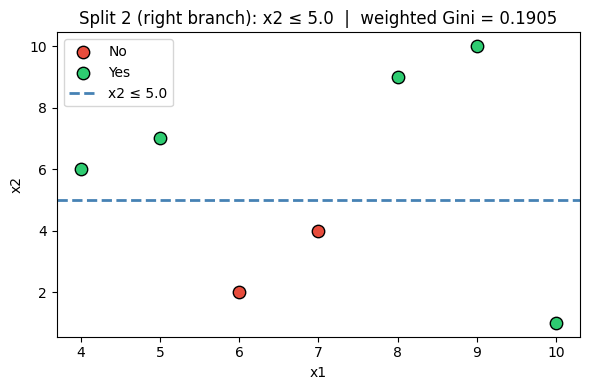

In [52]:
left2  = right1[right1[feat2] <= thresh2].copy()
right2 = right1[right1[feat2] >  thresh2].copy()

print(f"LEFT  ({feat2} ≤ {thresh2}): {len(left2)} points, Gini = {gini(left2['y']):.4f}")
print(left2[['x1','x2','y']].to_string(index=False))
print()
print(f"RIGHT ({feat2} > {thresh2}): {len(right2)} points, Gini = {gini(right2['y']):.4f}")
print(right2[['x1','x2','y']].to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
scatter_split(right1, feat2, thresh2,
              f'Split 2 (right branch): {feat2} ≤ {thresh2}  |  weighted Gini = {wg2}', ax)
plt.tight_layout()
plt.show()

---
## Split 3 — One Child is Still Mixed

After Split 2:
- **Right child** (`x2 > 4`) — pure Yes → **LEAF: predict Yes**  
- **Left child** (`x2 ≤ 4`) — still mixed (has both Yes and No) → needs one more split

We now run `find_best_split` on those remaining mixed points.

In [53]:
print("=== LEFT child of Split 2 (x2 ≤ 4) ===")
print(f"Labels: {left2['y'].tolist()}")
print(f"Gini  : {gini(left2['y']):.4f}")
print("→ still mixed, need another split\n")

print("=== RIGHT child of Split 2 (x2 > 4) ===")
print(f"Labels: {right2['y'].tolist()}")
print(f"Gini  : {gini(right2['y']):.4f}")
print("→ Gini = 0.0  →  LEAF NODE — predict 'Yes'")

=== LEFT child of Split 2 (x2 ≤ 4) ===
Labels: ['No', 'No', 'Yes']
Gini  : 0.4444
→ still mixed, need another split

=== RIGHT child of Split 2 (x2 > 4) ===
Labels: ['Yes', 'Yes', 'Yes', 'Yes']
Gini  : 0.0000
→ Gini = 0.0  →  LEAF NODE — predict 'Yes'


In [54]:
feat3, thresh3, wg3, results3 = find_best_split(left2)

print(f"Best split for left2 branch: {feat3} ≤ {thresh3}  →  weighted Gini = {wg3}\n")
print("All splits ranked:")
print(results3.to_string(index=False))

Best split for left2 branch: x1 ≤ 8.5  →  weighted Gini = 0.0

All splits ranked:
feature  threshold  left_gini  right_gini  weighted_gini
     x1        8.5        0.0         0.0         0.0000
     x2        1.5        0.0         0.0         0.0000
     x1        6.5        0.0         0.5         0.3333
     x2        3.0        0.5         0.0         0.3333


LEFT  (x1 ≤ 8.5): 2 points, Gini = 0.0000
 x1  x2  y
  6   2 No
  7   4 No

RIGHT (x1 > 8.5): 1 points, Gini = 0.0000
 x1  x2   y
 10   1 Yes

Both children are pure → both become LEAF NODES


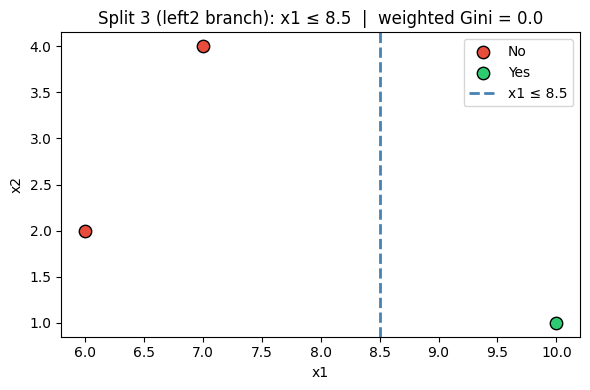

In [55]:
left3  = left2[left2[feat3] <= thresh3].copy()
right3 = left2[left2[feat3] >  thresh3].copy()

print(f"LEFT  ({feat3} ≤ {thresh3}): {len(left3)} points, Gini = {gini(left3['y']):.4f}")
print(left3[['x1','x2','y']].to_string(index=False))
print()
print(f"RIGHT ({feat3} > {thresh3}): {len(right3)} points, Gini = {gini(right3['y']):.4f}")
print(right3[['x1','x2','y']].to_string(index=False))
print()
print("Both children are pure → both become LEAF NODES")

fig, ax = plt.subplots(figsize=(6, 4))
scatter_split(left2, feat3, thresh3,
              f'Split 3 (left2 branch): {feat3} ≤ {thresh3}  |  weighted Gini = {wg3}', ax)
plt.tight_layout()
plt.show()

---
## The Full Tree

All branches are now pure. Below is the complete tree drawn with matplotlib — each box shows the split condition, the Gini at that node, and the sample count. Leaf nodes show the predicted class.

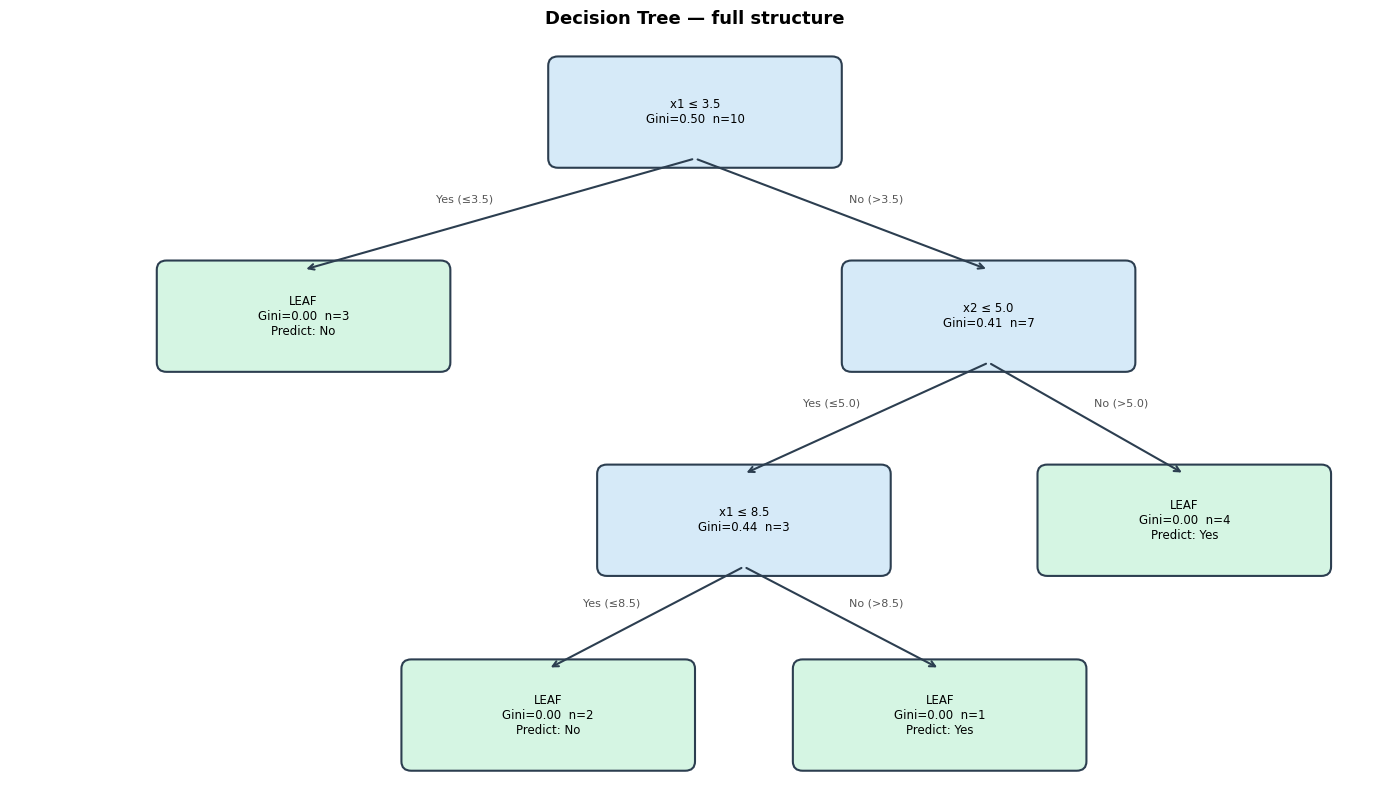

In [56]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

def draw_node(ax, cx, cy, text, color='#d6eaf8', width=2.8, height=1.0):
    box = mpatches.FancyBboxPatch(
        (cx - width/2, cy - height/2), width, height,
        boxstyle="round,pad=0.1", linewidth=1.5,
        edgecolor='#2c3e50', facecolor=color
    )
    ax.add_patch(box)
    ax.text(cx, cy, text, ha='center', va='center', fontsize=8.5,
            multialignment='center')

def draw_edge(ax, x1, y1, x2, y2, label='', side='left'):
    ax.annotate('', xy=(x2, y2 + 0.5), xytext=(x1, y1 - 0.5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
    mx, my = (x1+x2)/2, (y1+y2)/2
    offset = -0.35 if side == 'left' else 0.35
    ax.text(mx + offset, my + 0.1, label, fontsize=8, color='#555',
            ha='center', va='bottom')

leaf_color    = '#d5f5e3'
internal_color = '#d6eaf8'

# Root
draw_node(ax, 7, 7.2, f"x1 ≤ {thresh1}\nGini={root_gini:.2f}  n=10", internal_color)

# Level 1
draw_node(ax, 3,   5, f"LEAF\nGini=0.00  n=3\nPredict: No", leaf_color)
draw_node(ax, 10,  5, f"x2 ≤ {thresh2}\nGini={gini(right1['y']):.2f}  n=7", internal_color)

draw_edge(ax, 7, 7.2, 3,  5, 'Yes (≤3.5)', 'left')
draw_edge(ax, 7, 7.2, 10, 5, 'No (>3.5)',  'right')

# Level 2
draw_node(ax, 7.5, 2.8, f"x1 ≤ {thresh3}\nGini={gini(left2['y']):.2f}  n={len(left2)}", internal_color)
draw_node(ax, 12,  2.8, f"LEAF\nGini=0.00  n={len(right2)}\nPredict: Yes", leaf_color)

draw_edge(ax, 10, 5, 7.5, 2.8, f'Yes (≤{thresh2})', 'left')
draw_edge(ax, 10, 5, 12,  2.8, f'No (>{thresh2})',   'right')

# Level 3
draw_node(ax, 5.5, 0.7, f"LEAF\nGini=0.00  n={len(left3)}\nPredict: No",  leaf_color)
draw_node(ax, 9.5, 0.7, f"LEAF\nGini=0.00  n={len(right3)}\nPredict: Yes", leaf_color)

draw_edge(ax, 7.5, 2.8, 5.5, 0.7, f'Yes (≤{thresh3})', 'left')
draw_edge(ax, 7.5, 2.8, 9.5, 0.7, f'No (>{thresh3})',   'right')

ax.set_title('Decision Tree — full structure', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Validation — sklearn Decision Tree

We now train sklearn's `DecisionTreeClassifier` on the same dataset with `criterion='gini'` and no depth limit. Its `plot_tree` output should match the splits we found manually.

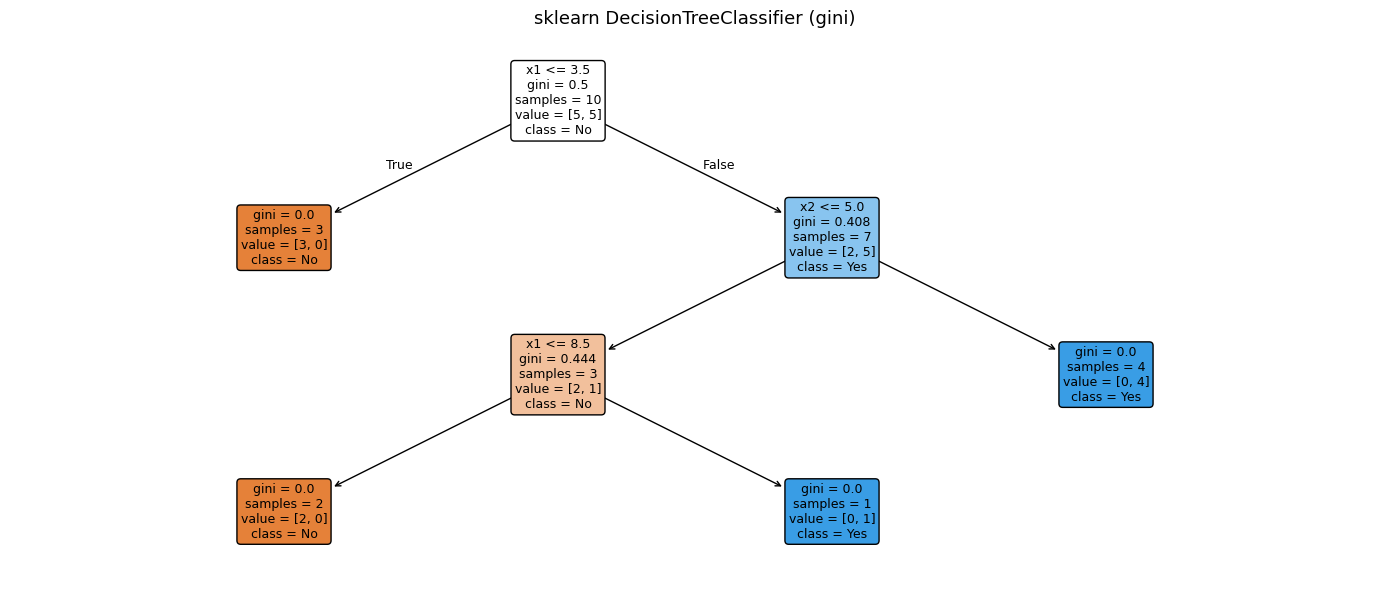


Our splits:   x1 ≤ 3.5  →  x2 ≤ 5.0  →  x1 ≤ 8.5
sklearn splits shown above — should match.


In [57]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = df[['x1', 'x2']].values
y_enc = (df['y'] == 'Yes').astype(int).values   # Yes=1, No=0

clf = DecisionTreeClassifier(criterion='gini', random_state=0)
clf.fit(X, y_enc)

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(clf, feature_names=['x1', 'x2'], class_names=['No', 'Yes'],
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title('sklearn DecisionTreeClassifier (gini)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nOur splits:   {feat1} ≤ {thresh1}  →  {feat2} ≤ {thresh2}  →  {feat3} ≤ {thresh3}")
print("sklearn splits shown above — should match.")